<a href="https://colab.research.google.com/github/kevinsu-rgb/Senior_Design_TI_Project/blob/main/dualchannel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Version with windowed-merged datasets making 55x1 input, Dense only model.
- data is merged so bins are all mixed up ...
- WINDOW_SIZE = 5, gives the merged-sorted result
- WINDOW_SIZE = 1, gives the concatenated result, no merging due to WINDOW=Frame size


In [ ]:
## All Hyper parameters

# Enumeration for each Category, \/\/\/\/\/\/ add new categories here along with data CSV's in folder of same name
class_data = {0: 'STANDING', 1: 'SITTING', 2: 'LYING', 3: 'FALLING', 4: 'WALKING'}

# Dataset feature formatting
WINDOW_SIZE = 8  # window size of frame data: 1,2,3,4,5,6 ... for example.
WINDOW_CONCATENATE = False  # concatenate each frame within the window or not (ie merge)
WINDOW_SORT = False  # Sort the window data or not (True or False)
MIN_POINTS = 5  # Minimum number of point cloud points for a row to be considered
EQUALISE_DATA_LENGTHS = False  # Set all categories to have the same rows as the fewest

# Heatmap parameters
HEATMAP_ENABLED = True # Enable or disable heatmap generation
HEATMAP_RESOLUTION = (10, 10) # Resolution of the heatmap (height, distance bins)

# Training topics
NUM_EPOCHS = 1600  # TRAINING: number of epochs to run
BATCH_SIZE = 64  # TRAINING: batch size of datasets defining the iterative model update, 64 is OK result.
TEST_SIZE_PERCENT = 20  # split dataset % between test(TEST_SIZE_PERCENT) and train(100-TEST_SIZE_PERCENT)
LEARNING_RATE = .0001  # Learning rate of the optimizer which determines the step size at each iteration while moving toward a minimum of a loss function
F1_SCORE_THRESH = 0.5  # Threshold for converting input into predicted labels for each sample.
# Compute binary f1 score, which is defined as the harmonic mean of precision and recall.

In [ ]:
import torch

torch.manual_seed(42)

import torch.nn as nn
import pandas as pd
from torch.optim import SGD
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import torch.onnx
import sys
from pathlib import Path
import os
import math

print(f"Python version: {sys.version}")
print(f"torch version: {torch.__version__}")
print(f"CUDA version: {torch.version.cuda}")
print(f"CPU instances: {os.cpu_count()}")

# setup module path for helper functions
# from modules.helper_functions import accuracy_fn

##################################################################
# If you have a GPU that supports CUDA, I heavily suggest you    #
# set device to CUDA rather than CPU for significantly increased #
# model training speeds                                          #
##################################################################

if torch.cuda.is_available():
  print(f"GPU: {torch.cuda.get_device_name(0)}, instances:{torch.cuda.device_count()}")
  device = "cuda"
else:
  device = "cpu"

torch.device(device)
print(f"New Device: {device}")

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
torch version: 2.9.0+cpu
CUDA version: None
CPU instances: 44
New Device: cpu


### Look for the dataset files and find the classes.

In [ ]:
# Setup path to data folder
data_path = Path(os.getcwd() + "/data")
print(data_path)
class_path = Path(f"{data_path}/classes/")

# Find the class names (according to folder structure)
class_names = [f for f in os.listdir(class_path)]

file_names = [f for f in list(class_path.rglob("*.csv"))]
print(f"File names: {file_names}")
print(f"# of Files: {len(file_names)}")


/content/data
File names: [PosixPath('/content/data/classes/SITTING/frames.csv'), PosixPath('/content/data/classes/STANDING/frames.csv')]
# of Files: 2


### Read in the data from the CSV files and concatenate into single dataframe
- Read in the CSV files and concatenate into one large dataset.
- Sort the rows by classification column.  
- separate the classes, and count how many of each classification are present.  
- Visualise the datasets.

In [ ]:
import ast
# %%writefile modules/data_setup.py
"""
Read in the data from the CSV files and concatenate into single dataframe
"""

## Read in the CSV files and concatenate into one large dataset.
## Remove collection information columns and add classification column
## Remove any rows with invalid data (not enough points or invalid track ID)
df_csv_append = pd.DataFrame()
heatmap_parser = lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else x
for file in file_names:
    df = pd.read_csv(file, encoding='utf-8', engine='python')

    if 'heatmap' in df.columns:
        df['heatmap'] = df['heatmap'].map(
            lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else x
        )

    folder_name = os.path.basename(os.path.dirname(file))
    df.insert(0, 'classification', folder_name)

    df_csv_append = pd.concat([df_csv_append, df])

df_csv_append = df_csv_append.sort_values(by='classification')
df_csv_append = df_csv_append.reset_index(drop=True) # TODO: fix the indices
print(df_csv_append)

    classification      posz      velx      vely      velz      accx  \
0          SITTING  0.170785  0.673322  0.018837 -0.946688  0.346935   
1          SITTING  0.136944 -0.282727 -0.289549 -0.196316 -0.301722   
2          SITTING  0.003707 -0.350082 -0.246254 -0.503115 -0.354486   
3          SITTING -0.016193 -0.380541 -0.268296 -0.479401 -0.339357   
4          SITTING -0.064004 -0.339516 -0.243135 -0.532056 -0.212178   
..             ...       ...       ...       ...       ...       ...   
417       STANDING -0.053569 -0.057902  0.059195 -0.332614 -0.013657   
418       STANDING -0.012584 -0.119084  0.031907 -0.141455 -0.127478   
419       STANDING -0.104398  0.195635 -0.271978 -0.320956  0.280820   
420       STANDING  0.205618 -0.018572  0.056976 -0.390426 -0.141772   
421       STANDING  0.292941  0.379880 -0.603414 -0.202928  0.423547   

         accy      accz       p1x       p1y  ...       p3x       p3y    p3z  \
0   -0.517937 -1.452380 -0.780605  2.355623  ... -0.1594

### Create feature and label arrays (ie X, y)
1. Convert dataframe data to lists, and concatenate the frame data into windows.
2. Create 2 arrays with X (input), y (output classification)
3. Convert lists to np arrays.
4. Turn our data into tensors for Pytorch.
5. Normalise the feature data so that it is (0 < X < 1)
6. Split our data into training and test sets (train a model on the training set to learn the patterns between `X` and `y` and then evaluate those learned patterns on the test dataset).
    Use `test_size=0.2` (80% training, 20% testing) and the split happens randomly across the data, so from run to run data will look different.


In [ ]:
X_pc_list = []
X_hm_list = []
y_list = []

for i, class_name in class_data.items():
    current_df = df_csv_append[df_csv_append['classification'] == class_name].copy()
    current_df = current_df.drop(columns=['classification'])
    current_df = current_df.reset_index(drop=True)

    for j in range(len(current_df) - WINDOW_SIZE + 1):
        window_df = current_df.iloc[i : i + WINDOW_SIZE]

        pc_window = window_df.iloc[:, :-1].values.flatten().tolist()

        hm_window = window_df.iloc[:, -1].values.tolist()

        X_pc_list.append(pc_window)
        X_hm_list.append(hm_window)
        y_list.append(i)


X_pc_np = np.array(X_pc_list, dtype=np.float32)
X_hm_np = np.array(X_hm_list, dtype=np.float32).reshape(-1, WINDOW_SIZE, 32, 32)
y_np = np.array(y_list, dtype=np.int64)
print(f"point cloud shape is {X_pc_np.shape}")
print(f"heatmap shape is {X_hm_np.shape}")
print(f"output shape is {y_np.shape}")

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1]
point cloud shape is (408, 176)
heatmap shape is (408, 8, 32, 32)
output shape is (408,)


### Format the data into DataLoaders for use in training
1. convert to dataset format
2. convert to dataloaders with batch size.

In [ ]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split # Import train_test_split

# Computing on batches of data, our loss and evaluation metrics will be calculated **per batch** rather than across the whole dataset.
# Need to divide our loss and accuracy values by the number of batches in each dataset's respective dataloader.

# Create the custom datasets, overload the len and getitem classes
class MyDataset(Dataset):
    def __init__(self, pc_data, heatmap_data, labels):
        self.xp = torch.tensor(pc_data, dtype=torch.float32)
        # Heatmaps need a "Channel" dimension for Conv2d: [Batch, 1, H, W]
        # For an item, heatmap_data will be (WINDOW_SIZE, 32, 32)
        # So unsqueeze(1) will make it (WINDOW_SIZE, 1, 32, 32)
        self.xh = torch.tensor(heatmap_data, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.xp[idx], self.xh[idx], self.y[idx]

FEATURE_COUNT = X_pc_np.shape[1] // WINDOW_SIZE
print(f"Calculated FEATURE_COUNT: {FEATURE_COUNT}")

X_train_pc, X_test_pc, X_train_hm, X_test_hm, y_train, y_test = train_test_split(
    X_pc_np, X_hm_np, y_np, test_size=TEST_SIZE_PERCENT / 100, random_state=42 # Use the global TEST_SIZE_PERCENT
)

print(f"Split data into train / test:   Train={100 - TEST_SIZE_PERCENT}% Test={TEST_SIZE_PERCENT}%")
print(f"X_train_pc shape: {X_train_pc.shape}, y_train shape: {y_train.shape}")
print(f"X_train_hm shape: {X_train_hm.shape}, y_train shape: {y_train.shape}")
print(f"X_test_pc shape: {X_test_pc.shape}, y_test shape: {y_test.shape}")
print(f"X_test_hm shape: {X_test_hm.shape}, y_test shape: {y_test.shape}")

train_dataset = MyDataset(X_train_pc, X_train_hm, y_train)
test_dataset = MyDataset(X_test_pc, X_test_hm, y_test)

# Create DataLoaders
train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

sample_pc, sample_hm, sample_labels = next(iter(train_dataloader))

print(f"\nPoint Cloud batch shape: {sample_pc.shape}")
print(f"Heatmap batch shape:     {sample_hm.shape}")
print(f"Labels batch shape:      {sample_labels.shape}")


Calculated FEATURE_COUNT: 22
Split data into train / test:   Train=80% Test=20%
X_train_pc shape: (326, 176), y_train shape: (326,)
X_train_hm shape: (326, 8, 32, 32), y_train shape: (326,)
X_test_pc shape: (82, 176), y_test shape: (82,)
X_test_hm shape: (82, 8, 32, 32), y_test shape: (82,)

Point Cloud batch shape: torch.Size([64, 176])
Heatmap batch shape:     torch.Size([64, 1, 8, 32, 32])
Labels batch shape:      torch.Size([64])


### Define the model
3 fully connected layers with batch normalization before each one

In [ ]:
import torch
import torch.nn as nn

class LinearModel(nn.Module):
    '''
    This is modified to have two branches...
    Point Cloud -> Linear -> Fusion -> Linear -> Out
    Heatmap -> Convlayer ->  ^
    '''
    def __init__(self, input_size, output_size):
        super(LinearModel, self).__init__()

        self.pc_branch = nn.Sequential(
            nn.BatchNorm1d(num_features=input_size),
            nn.Linear(in_features=input_size, out_features=64),
            nn.ReLU(),
            nn.BatchNorm1d(num_features=64),
            nn.Linear(in_features=64, out_features=32),
            nn.ReLU()
        )

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten()
        )

        combined_size = 32 + 512

        self.fusion_head = nn.Sequential(
            nn.Linear(combined_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, output_size)
        )

    def forward(self, xp, xh):
        out_p = self.pc_branch(xp) # Shape: [Batch, 32]

        # xh_shape: (BATCH_SIZE, 1, WINDOW_SIZE, 32, 32)
        # Reshape xh to treat each heatmap in the window as a separate item for Conv2d
        batch_size, channels, window_size, h, w = xh.shape
        xh_reshaped = xh.view(batch_size * window_size, channels, h, w) # Shape: (B*W, 1, 32, 32)

        out_h_per_frame = self.conv_layers(xh_reshaped) # Shape: (B*W, 512)

        # Aggregate the features from each frame in the window
        out_h = out_h_per_frame.view(batch_size, window_size, -1) # Shape: (B, W, 512)
        out_h = torch.mean(out_h, dim=1) # Aggregate by taking mean across window_size dimension. Shape: (B, 512)

        combined = torch.cat((out_p, out_h), dim=1)

        out = self.fusion_head(combined)

        return torch.softmax(out, dim=1)

In [ ]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """

    correct = (y_pred.argmax(dim=1) == y_true).sum().item()
    return correct / len(y_true) * 100

### Train the model

EPOCH: 0 | F1: 0.00000
Train loss: 1.59917 | Test loss: 1.85589, Test acc: 0.00%
Distance: 82
EPOCH: 160 | F1: 1.00000
Train loss: 1.53516 | Test loss: 1.54389, Test acc: 100.00%
Distance: 0
EPOCH: 320 | F1: 1.00000
Train loss: 1.45212 | Test loss: 1.45140, Test acc: 100.00%
Distance: 0
EPOCH: 480 | F1: 1.00000
Train loss: 1.35681 | Test loss: 1.36867, Test acc: 100.00%
Distance: 0
EPOCH: 640 | F1: 1.00000
Train loss: 1.29008 | Test loss: 1.26313, Test acc: 100.00%
Distance: 0
EPOCH: 800 | F1: 1.00000
Train loss: 1.18837 | Test loss: 1.19124, Test acc: 100.00%
Distance: 0
EPOCH: 960 | F1: 1.00000
Train loss: 1.15141 | Test loss: 1.12384, Test acc: 100.00%
Distance: 0
EPOCH: 1120 | F1: 1.00000
Train loss: 1.08093 | Test loss: 1.08701, Test acc: 100.00%
Distance: 0
EPOCH: 1280 | F1: 1.00000
Train loss: 1.09006 | Test loss: 1.04791, Test acc: 100.00%
Distance: 0
EPOCH: 1440 | F1: 1.00000
Train loss: 1.02369 | Test loss: 1.02744, Test acc: 100.00%
Distance: 0
EPOCH: 1599 | F1: 1.00000
Trai

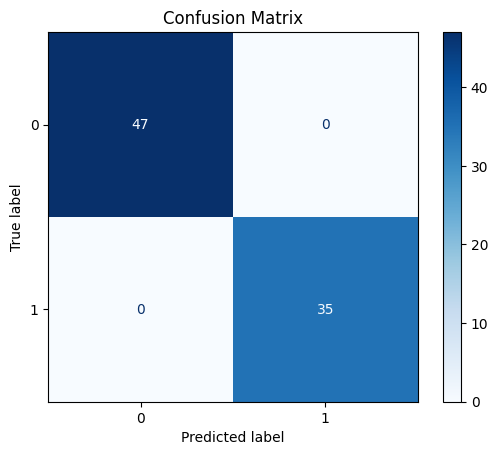

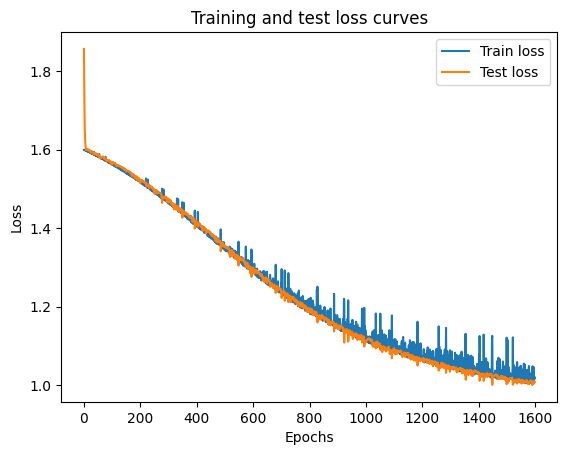

In [ ]:
!pip install torchmetrics
import torchmetrics
from torchmetrics.classification import MulticlassF1Score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Define model size and send to CPU
model_0 = LinearModel(input_size=WINDOW_SIZE * FEATURE_COUNT, output_size=len(class_data))

model_0.to(device)

loss_fn = nn.CrossEntropyLoss()

# setup the optimizer function
optimizer = SGD(params=model_0.parameters(), lr=LEARNING_RATE)
## Alternative optimizer.
# optimizer = Adam(params=model_0.parameters(), lr = LEARNING_RATE)

# setup F1 score
f1 = MulticlassF1Score(num_classes=len(class_data)).to(device)

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

###############################
# Start the main training loop
###############################
for epoch in range(NUM_EPOCHS):
    ### Training
    train_loss = 0

    for batch, (X_pc, X_hm, y) in enumerate(train_dataloader):
        model_0.train()

        X_pc, X_hm, y = X_pc.to(device), X_hm.to(device), y.to(device)
        y_pred = model_0(X_pc, X_hm)

        y = y.squeeze().long()

        loss = loss_fn(y_pred, y)
        train_loss += loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    train_loss /= len(train_dataloader)

    ### Testing
    test_loss, test_acc = 0, 0
    model_0.eval()

    all_preds = []
    all_labels = []
    distance = 0

    with torch.inference_mode():
        for X_pc, X_hm, y in test_dataloader:
            X_pc, X_hm, y = X_pc.to(device), X_hm.to(device), y.to(device)
            test_pred = model_0(X_pc, X_hm)

            y = y.squeeze().long()
            loss = loss_fn(test_pred, y)
            test_loss += loss_fn(test_pred, y)

            test_acc += accuracy_fn(y_true=y, y_pred=test_pred)

            predicted_labels = torch.argmax(test_pred, dim=1)

            all_preds.extend(predicted_labels)
            all_labels.extend(y)

            a = predicted_labels.tolist()
            b = y.tolist()

            for i in range(len(a)):
                if a[i] != b[i]:
                    distance += 1

        test_loss /= len(test_dataloader)

        test_acc /= len(test_dataloader)

    if epoch % (NUM_EPOCHS / 10) == 0 or epoch == NUM_EPOCHS - 1:
        print(f"EPOCH: {epoch} | F1: {f1(test_pred, y):.5f}")
        print(f"Train loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")
        print(f'Distance: {distance}')

    epoch_count.append(epoch)
    train_loss_values.append(train_loss.detach())
    test_loss_values.append(test_loss.detach())

if device == "cuda":
    all_labels = [x.item() for x in all_labels]
    all_preds = [x.item() for x in all_preds]
    train_loss_values = [x.item() for x in train_loss_values]
    test_loss_values = [x.item() for x in test_loss_values]

plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

In [ ]:
!pip install torchinfo
from torchinfo import summary

model_0 = LinearModel(input_size=WINDOW_SIZE * FEATURE_COUNT, output_size=len(class_data))

# more precise memory requirements - lists all parameters and datatypes to retrieve the bits/bytes used.
size_model = 0
for param in model_0.parameters():
    if param.data.is_floating_point():
        size_model += param.numel() * torch.finfo(param.data.dtype).bits
    else:
        size_model += param.numel() * torch.iinfo(param.data.dtype).bits
print(f"Model parameters size: {size_model} bits | {size_model / 8e3:.2f} KB")

# Overall summary of layers with Torchinfo.
# Provide input_size for both branches of the model
summary(model_0, input_size=[(1, WINDOW_SIZE * FEATURE_COUNT), (1, 1, WINDOW_SIZE, 32, 32)])

Model parameters size: 1728672 bits | 216.08 KB


Layer (type:depth-idx)                   Output Shape              Param #
LinearModel                              [1, 5]                    --
├─Sequential: 1-1                        [1, 32]                   --
│    └─BatchNorm1d: 2-1                  [1, 176]                  352
│    └─Linear: 2-2                       [1, 64]                   11,328
│    └─ReLU: 2-3                         [1, 64]                   --
│    └─BatchNorm1d: 2-4                  [1, 64]                   128
│    └─Linear: 2-5                       [1, 32]                   2,080
│    └─ReLU: 2-6                         [1, 32]                   --
├─Sequential: 1-2                        [8, 512]                  --
│    └─Conv2d: 2-7                       [8, 16, 32, 32]           160
│    └─ReLU: 2-8                         [8, 16, 32, 32]           --
│    └─MaxPool2d: 2-9                    [8, 16, 16, 16]           --
│    └─Conv2d: 2-10                      [8, 32, 16, 16]           4,640
│ 

**export the model**

In [ ]:
MODEL_PATH = "model.pth"
print(MODEL_PATH)
torch.save(model_0.state_dict(), "model.pth")

#with torch.no_grad():
#    torch.onnx.export(model_0, torch.randn(1, WINDOW_SIZE * FEATURE_COUNT).to(device), MODEL_PATH, opset_version=11)
#onnx_tool.model_profile(MODEL_PATH, save_profile="my_Linear-profile_relative.txt")


model.pth
